# Addestramento e valutazione del classificatore per predirre interazioni tra snoRNA (small nucleolar RNA) e lncRNA (long non-coding RNA)

#### Carichiamo i dati e le librerie necessarie per addestrare il modello.
#### Una libreria contiene sempre codice python, e mette a disposizione delle funzioni, che svolgono determinati compiti.

In [ ]:
!git clone https://github.com/NicoRota-0/DIGA_RNA
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from DIGA_RNA.interaction_training import TrainingConfig, train_model, test_model

folds_dir = f"DIGA_RNA/folds" # Questa directory deve contenere il file 'fold_0', dove sono salvate le sequenze di training e test
dict_path = 'DIGA_RNA/snorna-lncrna_dictionary_pooled_embeddings_RNAFM.p'   # Questo file contiene per ogni sequenza di RNA nel dataset, una rappresentazione estratta da RNA-FM

# training e test
if os.path.isdir(folds_dir):
    files = sorted([p for p in os.listdir(folds_dir) if p.endswith('.pkl')])
    fold = []
    for fn in files:
        with open(os.path.join(folds_dir, fn), 'rb') as fh:
            fold.append(pickle.load(fh))
    print(f"Loaded {len(fold)} per-fold pickles from {folds_dir}")
    fold = fold[0]
else:
    raise FileNotFoundError(f"directory {folds_dir} not found.")

# embeddings
if not os.path.exists(dict_path):
    raise FileNotFoundError(f"Embeddings dict not found at {dict_path}")
with open(dict_path, 'rb') as fh:
    embeddings_dict = pickle.load(fh)
print("Loaded embeddings dict with", len(embeddings_dict), "entries")

fatal: destination path 'DIGA_RNA' already exists and is not an empty directory.
Loaded 1 per-fold pickles from DIGA_RNA/folds
Loaded embeddings dict with 1102 entries


## Iperparametri e training
Quando una rete neurale viene addestrata, oltre ai dati in input, bisogna definire le specifiche della rete stessa, come per esempio: quante volde guardare l'intero dataset (epochs), o di quanti livelli è composta la rete (num_layers). 

Divisione Train/test: training usa molti esempi per apprendere la distribuzione dei dati e le regole dell'interazione. Nel test il modello non impara, ma verifica su esempi mai visti se la generalizzazione regge.

Intuizione: training = fase di apprendimento; test = fase di valutazione.

Analogia: studio = molti esercizi per costruire competenza; verifica = pochi esercizi per misurare la conoscenza.

In [ ]:
# definiamo la configurazione di training
config = TrainingConfig(
    num_layers=4,
    epochs=10
)
# lanciamo il training
train_artifacts = train_model(fold, embeddings_dict, config=config)


Device: cpu
Epoch 1/10 | Train=0.6856 | Val=0.6624 | LR=2.50e-04
Epoch 2/10 | Train=0.5908 | Val=0.4937 | LR=3.75e-04
Epoch 3/10 | Train=0.4799 | Val=0.4973 | LR=5.00e-04
Epoch 4/10 | Train=0.4253 | Val=0.4631 | LR=5.00e-04
Epoch 5/10 | Train=0.3681 | Val=0.4608 | LR=4.67e-04
Epoch 6/10 | Train=0.3341 | Val=0.4142 | LR=3.75e-04
Epoch 7/10 | Train=0.3009 | Val=0.3962 | LR=2.50e-04
Epoch 8/10 | Train=0.2696 | Val=0.4218 | LR=1.25e-04
Epoch 9/10 | Train=0.2584 | Val=0.4207 | LR=3.35e-05
Epoch 10/10 | Train=0.2458 | Val=0.4125 | LR=2.50e-08
Soglia ottimale: 0.35000000000000003


# Test del modello addestrato
## Il classificatore è stato addestrato sui dati di training, ora possiamo testare il suo funzionamento su dati che non ha mai visto (i dati di test): in questo modo possiamo capire se il classificatore può generalizzare a tutte le coppie di RNA che gli daremo in input.

In [ ]:
# testiamo il modello
test_results = test_model(
    train_artifacts.model,
    train_artifacts.test_loader,
    threshold=train_artifacts.threshold,
    device=train_artifacts.device,
)

test_probs = test_results.probabilities
test_labels = test_results.labels
test_pred = test_results.predictions
best_thr = train_artifacts.threshold


# Accuratezza del modello sui dati di test
L'accuratezza del modello sui dati di test è una metrica che indica quanto il modello è in grado di fare previsioni corrette su dati che non ha mai visto durante la fase di addestramento. In pratica, è la percentuale di previsioni esatte (sia interazioni positive che negative) che il modello fa su un set di dati indipendente, chiamato 'test set'.

È importante valutarla sui dati di test e non sui dati di training, perché l'accuratezza sul training set potrebbe essere fuorviante: un modello potrebbe aver semplicemente memorizzato i dati di addestramento (overfitting) e non essere in grado di generalizzare a nuove situazioni.

Una buona accuratezza sui dati di test suggerisce che il modello ha imparato pattern utili e può essere utilizzato per fare previsioni affidabili su nuove osservazioni.

In [ ]:
display(pd.DataFrame([test_results.metrics])[['accuracy']])

,accuracy
0,0.833333


### Precisione (Precision)

La **Precisione** misura la proporzione di identificazioni positivi che sono state effettivamente classificati correttamente. In altre parole, risponde alla domanda: "Di tutte le volte che il modello ha predetto 'Positivo', quante volte aveva ragione?".

È particolarmente importante in casi dove il costo di un falso positivo è alto (es. diagnosi medica: non vogliamo dire a una persona sana che è malata).

**Formula:**

$Precision = \frac{True Positives}{True Positives + False Positives}$

Dove:
- **True Positives (TP)**: Casi positivi correttamente identificati dal modello.
- **False Positives (FP)**: Casi negativi erroneamente identificati come positivi dal modello.

### Sensibilità (Recall)

La **sensibilità** misura la proporzione di casi positivi effettivi che sono stati correttamente identificati dal modello. Risponde alla domanda: "Di tutti i casi 'Positivi', quanti il modello è riuscito a identificare correttamente?".

È cruciale in scenari dove il costo di un falso negativo è alto (es. rilevamento di malattie gravi: non vogliamo perdere un vero positivo).

**Formula:**

$Recall = \frac{True Positives}{True Positives + False Negatives}$

Dove:
- **True Positives (TP)**: Casi positivi correttamente identificati dal modello.
- **False Negatives (FN)**: Casi positivi erroneamente identificati come negativi dal modello.

In [14]:
display(pd.DataFrame([test_results.metrics])[['precision', 'recall']])

,precision,recall
0,0.782241,0.925


### Matrice di Confusione

La **Matrice di Confusione** è uno strumento fondamentale per la valutazione delle prestazioni di un modello di classificazione. È una tabella che visualizza e riassume le prestazioni di un algoritmo di classificazione, mettendo a confronto i valori reali con quelli predetti dal modello.

In una matrice di confusione per un problema di classificazione binaria (come il nostro, dove si predice interazione o non interazione), si trovano tipicamente quattro valori:

*   **True Positives (TP)**: Il modello ha predetto correttamente la classe positiva. (Es. Ha predetto 'interazione' e c'era effettivamente un'interazione).
*   **True Negatives (TN)**: Il modello ha predetto correttamente la classe negativa. (Es. Ha predetto 'nessuna interazione' e non c'era effettivamente un'interazione).
*   **False Positives (FP)**: Il modello ha predetto erroneamente la classe positiva quando in realtà era negativa (errore di tipo I). (Es. Ha predetto 'interazione' ma non c'era).
*   **False Negatives (FN)**: Il modello ha predetto erroneamente la classe negativa quando in realtà era positiva (errore di tipo II). (Es. Ha predetto 'nessuna interazione' ma c'era un'interazione).

L'immagine generata dal codice qui sotto, mostra la matrice di confusione **normalizzata**, il che significa che i valori sono espressi come percentuali sul totale dei casi reali per ogni classe. Questo è utile per capire le proporzioni degli errori e dei successi rispetto alla distribuzione delle classi.

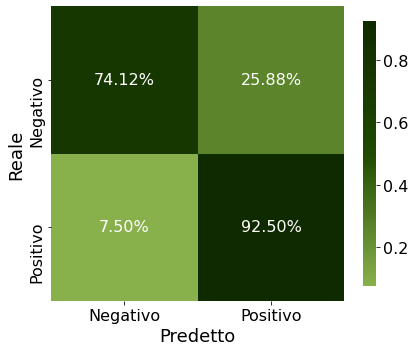

In [5]:
color_green = '#88B04B'
color_red = '#FF765B'
font_ticks = 16
font_labels = 18
custom_cmap = LinearSegmentedColormap.from_list('soft_oranges', ['#88B04B', '#204900', '#102A00'])

cm = test_results.confusion_matrix

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='.2%',
    cmap=custom_cmap,
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    annot_kws={'size': font_ticks},
    cbar_kws={'shrink': 0.9}
)

plt.xlabel('Predetto', fontsize=font_labels)
plt.ylabel('Reale', fontsize=font_labels)
plt.xticks(fontsize=font_ticks)
plt.yticks(fontsize=font_ticks)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelsize=font_ticks)

plt.tight_layout()
plt.show()


###  Boxplot delle Probabilità Predette

Il boxplot visualizza la distribuzione delle probabilità predette dal modello per le due classi: 'Negativo' e 'Positivo'.

**Componenti del Boxplot:**
*   **Box (scatola)**: Rappresenta la distribuzione dei dati.
*   **Linea all'interno della scatola**: Indica la mediana, ovvero il valore che divide dati ordinati in due metà uguali (50% sotto, 50% sopra).
*   **Baffi (whiskers)**: Si estendono dal box e mostrano la variabilità dei dati al di fuori della distribuzione.
*   **Punti esterni (outliers)**: Rappresentano i valori che cadono al di fuori dei baffi e sono considerati "anomali".

**Interpretazione nel contesto delle probabilità predette:**

*   **Boxplot per la classe 'Negativo' (rosso)**: Idealmente, ci aspettiamo che la maggior parte delle probabilità predette per le interazioni non presenti siano vicine a 0. Un boxplot con la scatola e i baffi concentrati vicino a 0 indica che il modello è confidente nel classificare queste istanze come negative.
*   **Boxplot per la classe 'Positivo' (verde)**: Idealmente, ci aspettiamo che la maggior parte delle probabilità predette per le interazioni presenti siano vicine a 1. Un boxplot con la scatola e i baffi concentrati vicino a 1 indica che il modello è confidente nel classificare queste istanze come positive.

Più i boxplot sono ristretti e spostati verso gli estremi (0 e 1 per le rispettive classi), più il modello è confidente. Al contrario, una maggiore dispersione o una concentrazione delle probabilità attorno alla soglia indica una minore sicurezza nelle previsioni del modello.

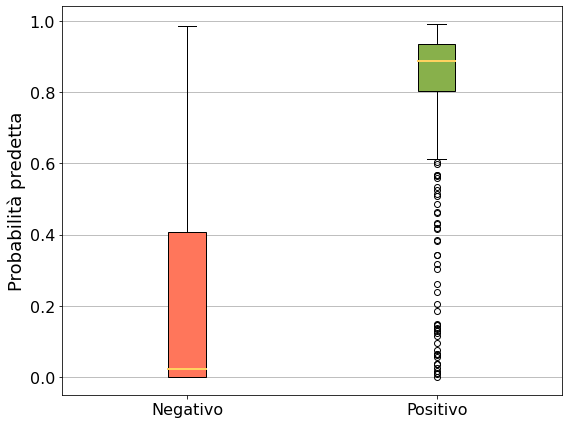

In [6]:
plt.figure(figsize=(8, 6))

box = plt.boxplot(
    [test_probs[test_labels == 0], test_probs[test_labels == 1]],
    labels=['Negativo', 'Positivo'],
    patch_artist=True
)

box['boxes'][0].set(facecolor=color_red)
box['boxes'][1].set(facecolor=color_green)

for median in box['medians']:
    median.set(color='#FFD260', linewidth=2)

plt.ylabel('Probabilità predetta', fontsize=font_labels)
plt.xticks(fontsize=font_ticks)
plt.yticks(fontsize=font_ticks)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Esercizio: Eseguire training su GPU.
Colab utilizza di default la CPU (Central Processing Unit): il processore del computer. Però esistono hardware dedicati e ottimizzati per addestrare modelli di reti neurali: le GPU (Graphical Processing Unit).

Esercizio: in alto a destra su COLAB, modifica il tipo di runtime, e seleziona quello con GPU. Prova a rieseguire il codice e guarda se il training viene eseguito più velocemente.

Curiosità: Le GPU sono state inizialmente create per gestire immagini e video, oggi però sono componenti principale nell'addestramento e uso dei Large Language Models, e di tutti i modelli di intelligenza artificiale.


# Esercizio: Modifica degli Iperparametri e Analisi dei Risultati

Per esplorare l'impatto degli iperparametri sulle prestazioni del modello, seguire i seguenti passaggi:

1.  **Modifica degli Iperparametri**: Modificare i valori di `epochs` e  `num_layers` nella cella di codice dove sono definiti gli iperparametri. Provs diversi valori per osservare come influenzano il training e i risultati.

2.  **Riaddestramento del Modello**: Eseguire nuovamente tutte le celle di codice a partire dalla definizione degli iperparametri fino al plotting dei grafici (incluse le celle di training e test del modello) per addestrare il modello con i nuovi valori.

3.  **Valutazione dei Nuovi Risultati**: Osservare le metriche di accuratezza, precisione e recall calcolate per il modello riaddestrato.

5.  **Documentazione delle Differenze**: Documentare le differenze osservate (Scrivile da qualche parte!) in termini di:
    *   **Accuratezza, Precisione e Recall e iperparametri usati**: Sono migliorate o peggiorate? Di quanto?

Attenzione! se una cella di codice viene ri-eseguita, i risultati si perdono! Quindi è meglio iniziare a scrivere i risultati attuali, e poi descrivere come vengono cambiati gli ipermarametri e i nuovi risultati.